In [1]:
from data_handling_raw import BorderDataset, prepare_dataset
from model_raw import BorderDetector
from utils_raw import EarlyStopping, TrainingMetrics, evaluate_model, save_checkpoint
from training_raw import train_model

import os
import json
import os
from datetime import datetime
import traceback

In [2]:
configs = [
    {
        'name': 'baseline_small',
        'conv_channels': [4, 8, 8],
        'fc_size': 64,  # Added fc_size
        'dropout_rate': 0.1,
        'learning_rate': 0.001,
        'weight_decay': 0.0001,
    },
    {
        'name': 'medium_more_augment',
        'conv_channels': [8, 16, 16],
        'fc_size': 128,  # Larger fc for larger conv channels
        'dropout_rate': 0.3,
        'learning_rate': 0.0005,
        'weight_decay': 0.001,
    },
    {
        'name': 'small_long_training',
        'conv_channels': [4, 8, 8],
        'fc_size': 64,
        'dropout_rate': 0.15,
        'learning_rate': 0.0005,
        'weight_decay': 0.0001,
    },
    {
        'name': 'medium_heavy_augment',
        'conv_channels': [8, 16, 16],
        'fc_size': 128,
        'dropout_rate': 0.2,
        'learning_rate': 0.0005,
        'weight_decay': 0.001,
    },
    {
        'name': 'tiny_deep',
        'conv_channels': [2, 4, 4],
        'fc_size': 32,  # Smaller fc for tiny model
        'dropout_rate': 0.1,
        'learning_rate': 0.001,
        'weight_decay': 0.0001,
    },
    {
        'name': 'micro_uniform',
        'conv_channels': [4, 4, 4],
        'fc_size': 32,
        'dropout_rate': 0.2,
        'learning_rate': 0.001,
        'weight_decay': 0.0001,
    },
    {
        'name': 'tiny_aggressive',
        'conv_channels': [2, 2, 4],
        'fc_size': 32,
        'dropout_rate': 0.1,
        'learning_rate': 0.002,
        'weight_decay': 0.00001,
    },
    {
        'name': 'small_pyramid',
        'conv_channels': [4, 6, 8],
        'fc_size': 64,
        'dropout_rate': 0.15,
        'learning_rate': 0.001,
        'weight_decay': 0.0001,
    }
]

common_config = {
    'grad_clip': 0.5,
    "num_epochs": 50,
    "num_rotations": 2,
    "accumulation_steps": 8,
    "patience": 15,
    "augment_brightness_contrast": True,
    "batch_size": 1,
}

for config in configs:
    config.update(common_config)

In [3]:
def run_experiment(config, experiment_name, main_output_dir):
    try:
        print(f"\nStarting experiment: {experiment_name}")
        
        # Create quantization-aware model if specified
        if config.get('quantize', False):
            print("Using quantization-aware training")
            config['qat_enabled'] = True
            
        model, metrics_tracker, model_output_dir = train_model(config)
        
        # If quantized, save both float and quantized versions
        if config.get('quantize', False):
            quantized_path = os.path.join(model_output_dir, 'model_quantized.pth')
            float_path = os.path.join(model_output_dir, 'model_float.pth')
            # Save paths will be handled in train_model
            
        return {
            'status': 'success',
            'experiment_name': experiment_name,
            'output_dir': model_output_dir,
            'final_val_loss': metrics_tracker.val_losses[-1],
            'final_val_accuracy': metrics_tracker.val_accuracies[-1],
            'training_history': metrics_tracker.to_dict(),
            'quantized': config.get('quantize', False)
        }
        
    except Exception as e:
        print(f"Error in experiment {experiment_name}: {str(e)}")
        print("\nFull traceback:")
        print(traceback.format_exc())
        # try again with a smaller learning rate if we haven't already
        if 'rerun' not in config and 'learning_rate' in config:
            config['learning_rate'] = config['learning_rate'] / 3
            config['rerun'] = True
            print(f"Retrying with smaller learning rate: {config['learning_rate']}")
            return run_experiment(config, experiment_name, main_output_dir)
        return {
            'status': 'failed',
            'experiment_name': experiment_name,
            'error': str(e)
        }

In [4]:
import json
import os
from datetime import datetime

# Create timestamp at the start
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
main_output_dir = f'experiments_raw/experiment_{timestamp}'
os.makedirs(main_output_dir, exist_ok=True)

# Run all experiments and collect results
results = []
for config in configs:
    experiment_name = config['name'] 
    print(f"\nRunning experiment: {experiment_name} with config: {config}")
    result = run_experiment(config, experiment_name, main_output_dir)
    
    # Save training history separately if experiment was successful
    if result['status'] == 'success':
        history_path = os.path.join(main_output_dir, f'{experiment_name}_history.json')
        with open(history_path, 'w') as f:
            json.dump(result['training_history'], f, indent=2)
        
        # Store the path to history file instead of full history in results
        result['history_path'] = history_path
    
    result['experiment_name'] = experiment_name
    result['config'] = config
    results.append(result)
    
    # Save intermediate results summary
    summary = {
        'timestamp': timestamp,
        'results': results
    }
    with open(os.path.join(main_output_dir, 'experiments_summary.json'), 'w') as f:
        json.dump(summary, f, indent=2)

# Print final summary
print("\n" + "="*50)
print("Experiments Summary:")
print("="*50)

successful_experiments = [r for r in results if r['status'] == 'success']
failed_experiments = [r for r in results if r['status'] == 'failed']

print(f"\nTotal experiments: {len(results)}")
print(f"Successful experiments: {len(successful_experiments)}")
print(f"Failed experiments: {len(failed_experiments)}")

if successful_experiments:
    print("\nSuccessful experiments results:")
    for result in successful_experiments:
        print(f"\nExperiment: {result['experiment_name']}")
        print(f"Final validation loss: {result['final_val_loss']:.4f}")
        print(f"Final validation accuracy: {result['final_val_accuracy']:.2f}%")
        print(f"Output directory: {result['output_dir']}")

if failed_experiments:
    print("\nFailed experiments:")
    for result in failed_experiments:
        print(f"\nExperiment: {result['experiment_name']}")
        print(f"Error: {result['error']}")

# Save final summary with paths to training histories
final_summary = {
    'timestamp': timestamp,
    'total_experiments': len(results),
    'successful_experiments': len(successful_experiments),
    'failed_experiments': len(failed_experiments),
    'results': results,  # Now includes paths to history files
    'best_model': None
}

if successful_experiments:
    best_result = min(successful_experiments, key=lambda x: x['final_val_loss'])
    final_summary['best_model'] = {
        'experiment_name': best_result['experiment_name'],
        'output_dir': best_result['output_dir'],
        'val_loss': best_result['final_val_loss'],
        'val_accuracy': best_result['final_val_accuracy'],
        'history_path': best_result.get('history_path')  # Include path to history file
    }

# Save final summary
with open(os.path.join(main_output_dir, 'final_summary.json'), 'w') as f:
    json.dump(final_summary, f, indent=2)


Running experiment: baseline_small with config: {'name': 'baseline_small', 'conv_channels': [4, 8, 8], 'fc_size': 64, 'dropout_rate': 0.1, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'grad_clip': 0.5, 'num_epochs': 50, 'num_rotations': 2, 'accumulation_steps': 8, 'patience': 15, 'augment_brightness_contrast': True, 'batch_size': 1}

Starting experiment: baseline_small
Initial memory state:
Memory usage: 510.9 MB
Using device: cpu
Loading and preprocessing dataset...


Processing unlabeled: 100%|██████████| 367/367 [00:00<00:00, 4304.24it/s]


Label distribution: {0: 668, 1: 648}

Memory before training:
Memory usage: 1037.7 MB


Epoch 46/50: 100%|██████████| 1052/1052 [00:03<00:00, 296.74it/s]


Early stopping triggered

Final metrics:
Train Loss: 7.7679, Val Loss: 48.0158
Train Accuracy: 51.81%, Val Accuracy: 50.76%
Learning Rate: 0.000692

Running experiment: medium_more_augment with config: {'name': 'medium_more_augment', 'conv_channels': [8, 16, 16], 'fc_size': 128, 'dropout_rate': 0.3, 'learning_rate': 0.0005, 'weight_decay': 0.001, 'grad_clip': 0.5, 'num_epochs': 50, 'num_rotations': 2, 'accumulation_steps': 8, 'patience': 15, 'augment_brightness_contrast': True, 'batch_size': 1}

Starting experiment: medium_more_augment
Initial memory state:
Memory usage: 641.1 MB
Using device: cpu
Loading and preprocessing dataset...


...

Early stopping triggered

Final metrics:
Train Loss: 0.1113, Val Loss: 0.8216
Train Accuracy: 97.62%, Val Accuracy: 91.29%
Learning Rate: 0.001809

Running experiment: small_pyramid with config: {'name': 'small_pyramid', 'conv_channels': [4, 6, 8], 'fc_size': 64, 'dropout_rate': 0.15, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'grad_clip': 0.5, 'num_epochs': 50, 'num_rotations': 2, 'accumulation_steps': 8, 'patience': 15, 'augment_brightness_contrast': True, 'batch_size': 1}

Starting experiment: small_pyramid
Initial memory state:
Memory usage: 769.6 MB
Using device: cpu
Loading and preprocessing dataset...


Processing unlabeled: 100%|██████████| 367/367 [00:00<00:00, 4282.58it/s]


Label distribution: {0: 668, 1: 648}

Memory before training:
Memory usage: 1203.6 MB


Epoch 49/50: 100%|██████████| 1052/1052 [00:03<00:00, 306.37it/s]


Early stopping triggered

Final metrics:
Train Loss: 8.2582, Val Loss: 53.4091
Train Accuracy: 48.76%, Val Accuracy: 46.59%
Learning Rate: 0.000579

Experiments Summary:

Total experiments: 8
Successful experiments: 8
Failed experiments: 0

Successful experiments results:

Experiment: baseline_small
Final validation loss: 48.0158
Final validation accuracy: 50.76%
Output directory: results_raw/training_output_20250316_150249

Experiment: medium_more_augment
Final validation loss: 0.3450
Final validation accuracy: 92.42%
Output directory: results_raw/training_output_20250316_150545

Experiment: small_long_training
Final validation loss: 0.1314
Final validation accuracy: 95.83%
Output directory: results_raw/training_output_20250316_150749

Experiment: medium_heavy_augment
Final validation loss: 41.7275
Final validation accuracy: 49.24%
Output directory: results_raw/training_output_20250316_150930

Experiment: tiny_deep
Final validation loss: 0.1669
Final validation accuracy: 97.73%
Output

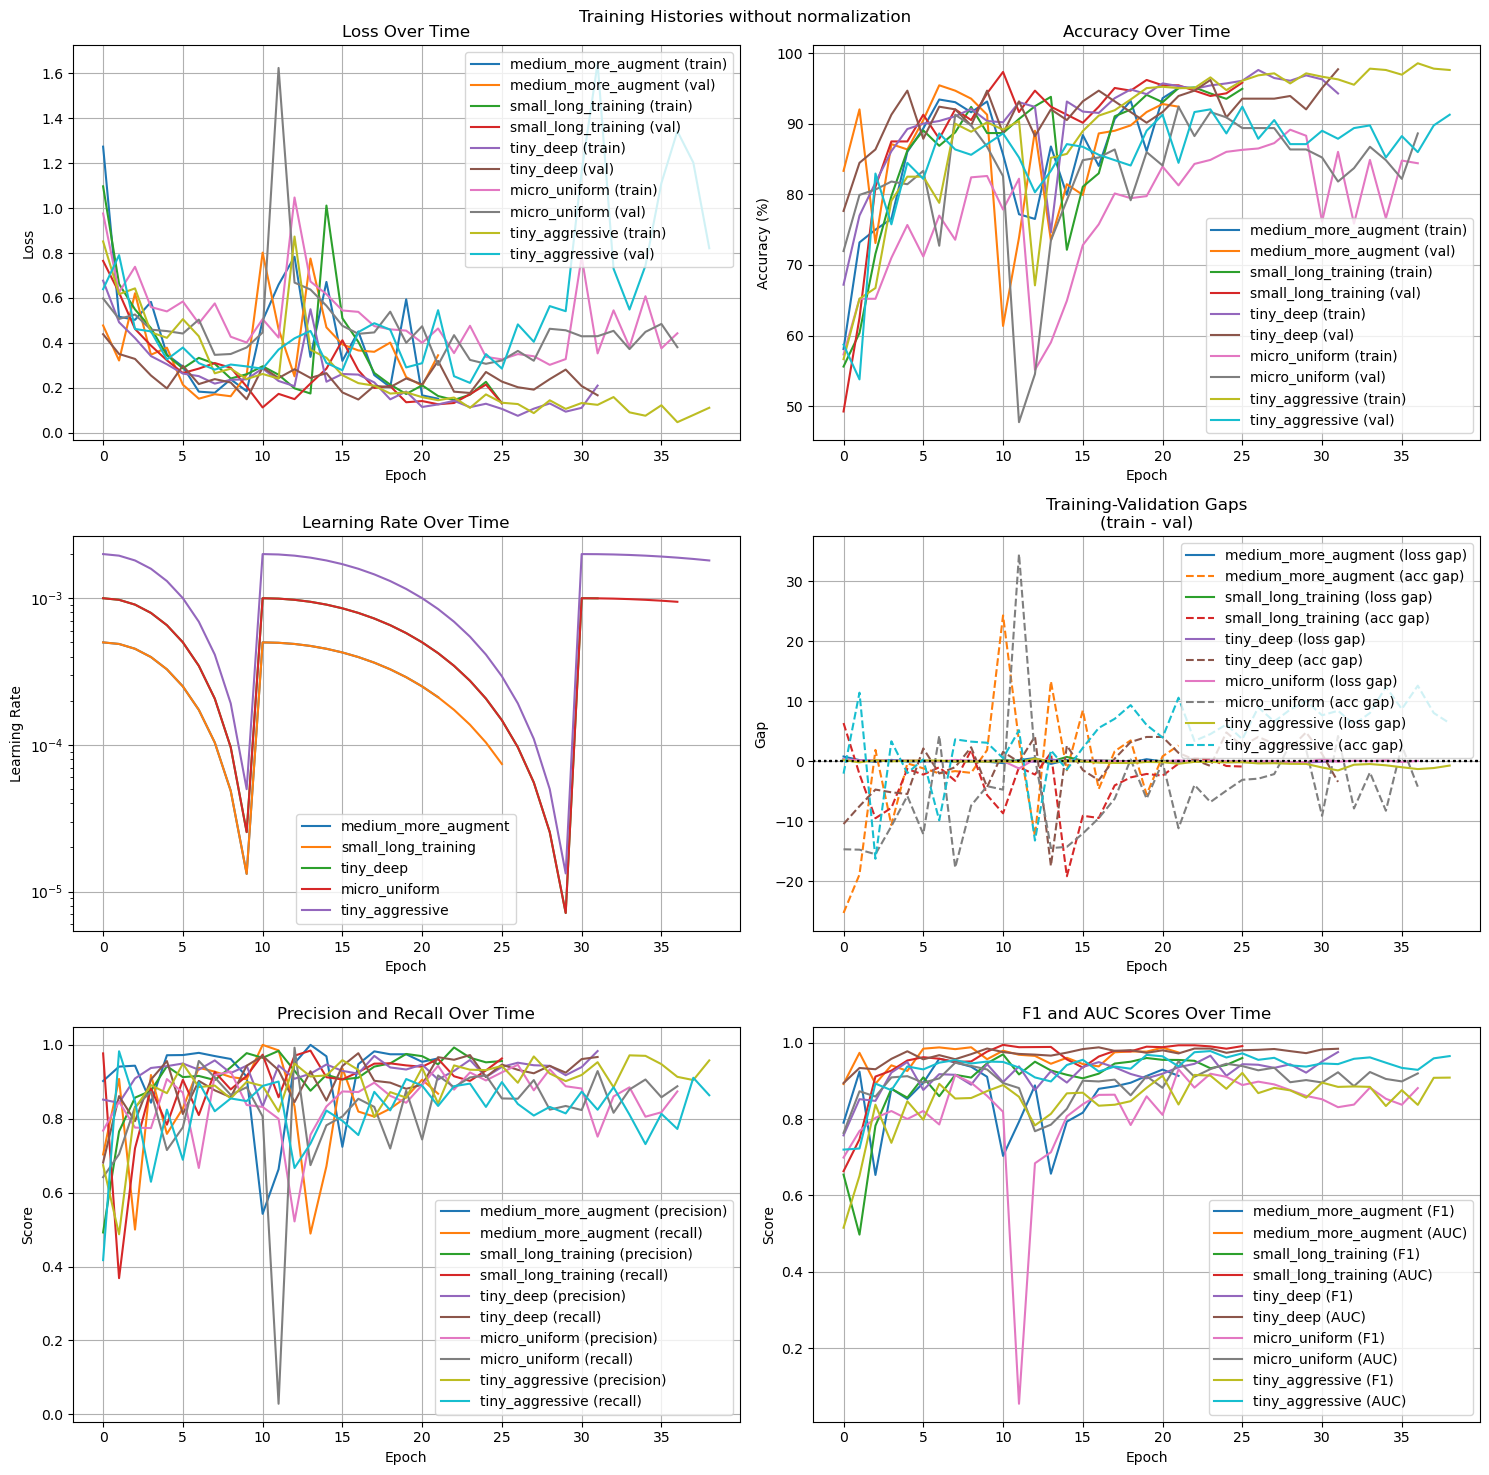

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def load_experiment_histories(experiment_dir):
    # Load the summary file
    with open(os.path.join(experiment_dir, 'final_summary.json'), 'r') as f:
        summary = json.load(f)
    
    histories = {}
    for result in summary['results']:
        if result['status'] == 'success' and 'history_path' in result:
            with open(result['history_path'], 'r') as f:
                histories[result['experiment_name']] = json.load(f)
    
    return histories, summary

def plot_experiment_histories(histories):
    """
    Plot training histories including additional metrics if available.
    """
    # Check what additional metrics are available
    additional_metrics = []
    for history in histories.values():
        additional_metrics.extend([k for k in history.keys() 
                                if k.startswith(('val_precision', 'val_recall', 'val_f1', 'val_auc'))])
    additional_metrics = list(set(additional_metrics))

    # filter out histories with low val_auc
    histories = {k: v for k, v in histories.items() if v['val_auc_scores'][-1] > 0.7}
    
    # Create figure with correct number of subplots
    n_rows = 3 if additional_metrics else 2  # Add one more row for additional metrics
    fig, axes = plt.subplots(n_rows, 2, figsize=(15, 5*n_rows))
    
    # Plot basic metrics
    for exp_name, history in histories.items():
        # Loss plot
        axes[0,0].plot(history['train_losses'], label=f'{exp_name} (train)')
        axes[0,0].plot(history['val_losses'], label=f'{exp_name} (val)')
        axes[0,0].set_title('Loss Over Time')
        axes[0,0].set_xlabel('Epoch')
        axes[0,0].set_ylabel('Loss')
        axes[0,0].legend()
        axes[0,0].grid(True)
        
        # Accuracy plot
        axes[0,1].plot(history['train_accuracies'], label=f'{exp_name} (train)')
        axes[0,1].plot(history['val_accuracies'], label=f'{exp_name} (val)')
        axes[0,1].set_title('Accuracy Over Time')
        axes[0,1].set_xlabel('Epoch')
        axes[0,1].set_ylabel('Accuracy (%)')
        axes[0,1].legend()
        axes[0,1].grid(True)
        
        # Learning rate plot
        axes[1,0].plot(history['learning_rates'], label=exp_name)
        axes[1,0].set_title('Learning Rate Over Time')
        axes[1,0].set_xlabel('Epoch')
        axes[1,0].set_ylabel('Learning Rate')
        axes[1,0].set_yscale('log')
        axes[1,0].legend()
        axes[1,0].grid(True)
        
        # Training-validation gaps
        loss_gap = np.array(history['train_losses']) - np.array(history['val_losses'])
        acc_gap = np.array(history['train_accuracies']) - np.array(history['val_accuracies'])
        axes[1,1].plot(loss_gap, label=f'{exp_name} (loss gap)')
        axes[1,1].plot(acc_gap, label=f'{exp_name} (acc gap)', linestyle='--')
        axes[1,1].set_title('Training-Validation Gaps\n(train - val)')
        axes[1,1].set_xlabel('Epoch')
        axes[1,1].set_ylabel('Gap')
        axes[1,1].legend()
        axes[1,1].grid(True)
        axes[1,1].axhline(y=0, color='k', linestyle=':')
        
        # Additional metrics plot
        if additional_metrics:
            # Precision/Recall plot
            axes[2,0].plot(history['val_precisions'], label=f'{exp_name} (precision)')
            axes[2,0].plot(history['val_recalls'], label=f'{exp_name} (recall)')
            axes[2,0].set_title('Precision and Recall Over Time')
            axes[2,0].set_xlabel('Epoch')
            axes[2,0].set_ylabel('Score')
            axes[2,0].legend()
            axes[2,0].grid(True)
            
            # F1 and AUC plot
            axes[2,1].plot(history['val_f1_scores'], label=f'{exp_name} (F1)')
            axes[2,1].plot(history['val_auc_scores'], label=f'{exp_name} (AUC)')
            axes[2,1].set_title('F1 and AUC Scores Over Time')
            axes[2,1].set_xlabel('Epoch')
            axes[2,1].set_ylabel('Score')
            axes[2,1].legend()
            axes[2,1].grid(True)
    
    plt.suptitle('Training Histories without normalization')
    plt.tight_layout()
    plt.show()

# Example usage:
experiment_dir = 'experiments_raw/experiment_20250316_150249'

# experiment_dir = 'experiments/experiment_20250313_105140'
histories, summary = load_experiment_histories(experiment_dir)

# Plot and save
plot_experiment_histories(
    histories
)

In [23]:
import os
import json
import matplotlib.pyplot as plt
import torch

results = os.listdir('results_raw')
results = sorted(results)[-8:]
results = [os.path.join('results_raw', r) for r in results]

for result in results:
    with open(os.path.join(result, 'metrics.json'), 'r') as f:
        metrics = json.load(f)
    # get best val_auc_scores index
    best_val_auc = max(metrics['val_auc_scores'])
    best_val_auc_index = metrics['val_auc_scores'].index(best_val_auc)
    # get best model from best val auc index
    model_path = os.path.join(result, f'checkpoint_epoch_{best_val_auc_index+1}.pt')
    checkpoint = torch.load(model_path)
    state_dict = checkpoint['model_state_dict']
    
    # Create model with same architecture as saved model
    config = {
        'conv_channels': [
            state_dict['conv1.weight'].shape[0],
            state_dict['conv2.weight'].shape[0],
            state_dict['conv3.weight'].shape[0]
        ],
        'fc_size': state_dict['fc1.weight'].shape[0],
        'dropout_rate': 0.1
    }
    
    model = BorderDetector(config)
    model.load_state_dict(state_dict)
    model.eval()  # Set to evaluation mode
    
    # Feed dummy input
    dummy_input = torch.randn(1, 3, 120, 120)
    with torch.no_grad():
        output = model(dummy_input)
    
    print(f"\nModel from: {os.path.basename(result)}")
    print(f"Parameters: {model.count_parameters():,}")
    print(f"Best validation AUC: {best_val_auc:.4f}")
    print(f"Output shape: {output.shape}")

    


Model from: training_output_20250316_150249
Parameters: 116,321
Best validation AUC: 0.9888
Output shape: torch.Size([1, 1])

Model from: training_output_20250316_150545
Parameters: 464,769
Best validation AUC: 0.9878
Output shape: torch.Size([1, 1])

Model from: training_output_20250316_150749
Parameters: 116,321
Best validation AUC: 0.9940
Output shape: torch.Size([1, 1])

Model from: training_output_20250316_150930
Parameters: 464,769
Best validation AUC: 0.9847
Output shape: torch.Size([1, 1])

Model from: training_output_20250316_151130
Parameters: 29,145
Best validation AUC: 0.9876
Output shape: torch.Size([1, 1])

Model from: training_output_20250316_151309
Parameters: 29,273
Best validation AUC: 0.9509
Output shape: torch.Size([1, 1])

Model from: training_output_20250316_151511
Parameters: 29,035
Best validation AUC: 0.9778
Output shape: torch.Size([1, 1])

Model from: training_output_20250316_151709
Parameters: 116,103
Best validation AUC: 0.5000
Output shape: torch.Size([1,

/tmp/ipykernel_200629/1554954011.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path)
